In [80]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

from cdvae.common.utils import PROJECT_ROOT
from cdvae.common.data_utils import (
    EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
    frac_to_cart_coords, min_distance_sqr_pbc)
from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

#added by Tsach
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
#import Batch
from torch_geometric.data import Batch
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
torch.set_printoptions(threshold=50000) # use this if you want to print the entire tensor

import time
import argparse
import torch

from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
from types import SimpleNamespace
from torch_geometric.data import Batch
from torch_geometric.data.separate import separate

#import a library that allows you to reload a module
from importlib import reload

from eval_utils import load_model

import itertools
import numpy as np
import torch
import hydra

from scipy.spatial.distance import pdist
from scipy.spatial.distance import cdist
from hydra.experimental import compose
from hydra import initialize_config_dir
from pathlib import Path

import smact
from smact.screening import pauling_test

from cdvae.common.constants import CompScalerMeans, CompScalerStds
from cdvae.common.data_utils import StandardScaler, chemical_symbols
#from cdvae.pl_data.dataset import TensorCrystDataset
from cdvae.pl_data.datamodule import worker_init_fn

from torch_geometric.data import DataLoader

CompScaler = StandardScaler(
    means=np.array(CompScalerMeans),
    stds=np.array(CompScalerStds),
    replace_nan_token=0.)


In [86]:
def load_model(model_path, load_data=False, testing=True, test_set_override=None):
    with initialize_config_dir(str(model_path)):
        if test_set_override is not None:
            cfg = compose(config_name='hparams', overrides=[f"data.root_path=/home/gridsan/tmackey/cdvae/data/{test_set_override}",
                                                            f"data.eval_model_name={test_set_override}"])
            print("overriding data with ", test_set_override)
        else:
            cfg = compose(config_name='hparams')
        model = hydra.utils.instantiate(
            cfg.model,
            optim=cfg.optim,
            data=cfg.data,
            logging=cfg.logging,
            _recursive_=False,
        )
        ckpts = list(model_path.glob('*.ckpt'))
        if len(ckpts) > 0:
            ckpt_epochs = np.array(
                [int(ckpt.parts[-1].split('-')[0].split('=')[1]) for ckpt in ckpts])
            ckpt = str(ckpts[ckpt_epochs.argsort()[-1]])
        model = model.load_from_checkpoint(ckpt, strict=False)
        model.lattice_scaler = torch.load(model_path / 'lattice_scaler.pt')
        model.scaler = torch.load(model_path / 'prop_scaler.pt')

        if load_data:
            datamodule = hydra.utils.instantiate(
                cfg.data.datamodule, _recursive_=False, scaler_path=model_path
            )
            if testing:
                datamodule.setup()
                print(datamodule)
                print(datamodule.train_dataloader())
                test_loader = datamodule.train_dataloader()
                print(test_loader)
            else:
                datamodule.setup()
                test_loader = datamodule.train_dataloader()[0]
        else:
            test_loader = None

    return model, test_loader, cfg

In [87]:
import importlib 
import eval_utils
importlib.reload(eval_utils)
model_path = Path("/home/gridsan/tmackey/hydra/singlerun/2024-01-11/augcag/")
model, test_loader, cfg = load_model(model_path, True, test_set_override = "mp_20")

loader = test_loader

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


overriding data with  mp_20
the noise_sd is: 0.01
the noise_sd is: 0.01
constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/tmackey/cdvae/data/mp_20/train_20_any.csv
using existing graph file  /home/gridsan/tmackey/cdvae/data/mp_20/train_20_any.pt
no filter
using 27136 rows given a train_fraction of 1
[Errno 2] No such file or directory: '/home/gridsan/tmackey/cdvae/data/mp_20/train_xrd_peak_intensities_dict.pt'
time taken: 21.097105979919434
constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/tmackey/cdvae/data/mp_20/val_20_any.csv
using existing graph file  /home/gridsan/tmackey/cdvae/data/mp_20/val_20_any.pt
no filter
using 9047 rows given a train_fraction of 1
[Errno 2] No such file or directory: '/home/gridsan/tmackey/cdvae/data/mp_20/val_xrd_peak_intensities_dict.pt'
time taken: 7.060879707336426
constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/tmackey/cdvae/dat

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/torch_geometric/deprecation.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [88]:
model.to('cuda:0')

CDVAE(
  (simple_conv_net): SimpleConvNet(
    (conv_layers): Sequential(
      (0): Conv1d(1, 80, kernel_size=(100,), stride=(5,))
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Conv1d(80, 80, kernel_size=(50,), stride=(5,))
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
      (6): Conv1d(80, 80, kernel_size=(25,), stride=(2,))
      (7): ReLU()
      (8): Dropout(p=0.3, inplace=False)
    )
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (MLP): Sequential(
      (0): Linear(in_features=12160, out_features=2300, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=2300, out_features=1150, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.5, inplace=False)
      (6): Linear(in_features=1150, out_features=256, bias=True)
    )
  )
  (encoder): DimeNetPlusPlusWrap(
    (rbf): BesselBasisLayer(
      (envelope): Envelope()
    )
    (sbf): SphericalBasisLayer(
      (envelope): Envelope()
    )
    (em

In [89]:
list_of_idxs = []
list_of_batchs = []

In [90]:
for idx, batch in enumerate(loader):
    print(idx)
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)

idx = list_of_idxs[0]
batch = list_of_batchs[0]


def new_dataloader_batch_processor(batch): 
    batch_reserve = batch
    xrd_int = batch_reserve[1]
    xrd_loc = batch_reserve[2]
    atom_spec = batch_reserve[3]
    batch = batch[0]
    disc_sim_xrd = batch_reserve[4]
    pv_xrd = batch_reserve[5]

    return batch_reserve, xrd_int, xrd_loc, atom_spec, batch, disc_sim_xrd, pv_xrd

batch_reserve, xrd_int, xrd_loc, atom_spec, batch, disc_sim_xrd, pv_xrd = new_dataloader_batch_processor(batch)

all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

batch_all_frac_coords = []
batch_all_atom_types = []
batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
batch_lengths, batch_angles = [], []

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105


In [91]:
xrd_int = xrd_int.cuda()
xrd_loc = xrd_loc.cuda()
atom_spec = atom_spec.cuda()
disc_sim_xrd = disc_sim_xrd.cuda()
batch = batch.cuda()
pv_xrd = pv_xrd.cuda()
print(atom_spec)

tensor([[12, 81, 62,  ...,  0,  0,  0],
        [ 6, 38,  0,  ...,  0,  0,  0],
        [39, 47, 81,  ...,  0,  0,  0],
        ...,
        [50, 89, 11,  ...,  0,  0,  0],
        [37, 81, 21,  ...,  0,  0,  0],
        [ 9, 64,  8,  ...,  0,  0,  0]], device='cuda:0')


In [92]:
"""
Bi 6
Si 8
Pb 4
PdBi2 12
FeO 8
V2O5 14
Ni 4
Fe 2
NiSb 4
NiPb 4
NiBi 4
InBi 4
In2Bi 6
NiBi3 16
InSb 8
Ba2ZrS4 14
BaBi3 4
Ti4CoBi2 28
MnBi 4
KBi2 24"""

num_atoms = [6,8,4,12,8,8,14,4,6,14,2,4,8,4,6,6,6,4,4,6,16,8,8,14,14,4,6,4,28,6,4,12,24,6,6,6]
atom_spec = [[83], [14], [82],[46,83],[26,8],[26,8],[23,8],[28],[83],[23,8],[26],[28,51],[26,8],[23,8],[28,82],[83],[83],[83],[28,83],[49,83],[49,83],[28,83],[49,51],[26,8],[56,40,16],[49,83],[83],[56,83],[22,27,83],[83],[25,83],[46,83],[19,83],[83],[83],[83]]

In [93]:
#load in the training dataframe to make sure none of the experimental compounds are in there 
train_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20/train.csv")

cif_dir = "/home/gridsan/tmackey/CIFs_good_patterns/"

from pymatgen.core.structure import Structure
import os

# Directory containing the CIF files
cif_dir = "/home/gridsan/tmackey/CIFs_good_patterns/"

# List to store pymatgen crystal objects
crystal_objects = []

# Looping through each file in the directory
for filename in os.listdir(cif_dir):
    if filename.endswith(".cif"):
        file_path = os.path.join(cif_dir, filename)
        try:
            # Create pymatgen crystal object and add it to the list
            crystal = Structure.from_file(file_path)
            crystal_objects.append(crystal)
        except Exception as e:
            print(f"Error processing {filename}: {e}")


import ast

train_df['atomic_numbers'] = train_df['atomic_numbers'].apply(ast.literal_eval)

train_df['atomic_numbers'] = train_df['atomic_numbers'].apply(sorted)

elements_atomic_numbers = []

for crystal in crystal_objects:
    # List for atomic numbers in the current crystal
    atomic_numbers = []

    for site in crystal:
        # Get the atomic number and add it to the list
        atomic_number = site.specie.number
        atomic_numbers.append(atomic_number)

    # Add the list of atomic numbers to the master list
    elements_atomic_numbers.append(atomic_numbers)


elements_atomic_numbers = [sorted(lillist) for lillist in elements_atomic_numbers]

# Assuming train_df is your DataFrame and elements_atomic_numbers is the list of lists

# Create a new column to store the result of the check
train_df['in_elements_atomic_numbers'] = train_df['atomic_numbers'].apply(
    lambda x: x in elements_atomic_numbers
)

# Now, train_df has an additional column 'in_elements_atomic_numbers' 
# with True or False depending on whether the entry in 'atomic_numbers' 
# was found in elements_atomic_numbers

#load in the training pseudo-voights 
training_pseudo_voights = torch.load("/home/gridsan/tmackey/cdvae/data/mp_20/train_pv_xrd.pt")

experimental_crossover = train_df[train_df['in_elements_atomic_numbers'] == True]

#training pseudo voights 
simulated_pvs = {training_pseudo_voights[key] for key in experimental_crossover['material_id']}

experimental_crossover['atomic_numbers']

num_atoms = [len(sublist) for sublist in experimental_crossover['atomic_numbers']]

gt_atom_spec = [list(set(sublist)) for sublist in experimental_crossover['atomic_numbers']]

gt_atom_spec = [(sublist + [0]*256)[:256] for sublist in gt_atom_spec]

#convert gt_atom_spec to a tensor 
stacked_version = np.stack(gt_atom_spec)

gt_atom_spec_torch = torch.tensor(stacked_version)

gt_num_atoms = torch.tensor(num_atoms)
gt_atom_types = None

gt_atom_spec_torch = gt_atom_spec_torch.cuda()
gt_num_atoms = gt_num_atoms.cuda()

pv_xrds = list(simulated_pvs)

pv_xrds = np.stack(pv_xrds)
pv_xrds = torch.tensor(pv_xrds).cuda()

pv_xrd = pv_xrds

num_evals = 1

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


In [143]:
list_of_idxs = []
list_of_batchs = []
list_of_batches_actually = []
complete_batch_list = []

In [144]:
for idx, batch in enumerate(loader):
    print(idx)
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)
    list_of_batches_actually.append(batch[0])
    complete_batch_list += batch[0].to_data_list()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105


In [145]:
len(complete_batch_list)

27136

In [226]:
all_crystals = []
for index, batch in enumerate(complete_batch_list): 
    # print(batch)
    # print(list(batch.atom_types.numpy()))
    all_crystals.append( list(batch.atom_types.numpy()))

In [227]:
len(all_crystals)

27136

In [228]:
all_crystals = [sorted(lillist) for lillist in all_crystals]

In [229]:
np.where(batch_crossover)

(array([ 2975,  7708,  8757, 13929, 13949, 14110, 16060, 17409, 18719,
        22371, 22435, 24910, 25320, 25961, 26894]),)

In [230]:
len(all_crystals)

27136

In [231]:
len(complete_batch_list)

27136

In [271]:
len(elements_atomic_numbers)

21

In [286]:
batch_list_just_crossover = []

for element in experimental_crossover['atomic_numbers']:
    if element in all_crystals:
        index = all_crystals.index(element)
        batch_list_just_crossover.append(complete_batch_list[index])

In [287]:
len(batch_list_just_crossover)

15

In [288]:
experimental_crossover

,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,disc_sim_xrd,in_elements_atomic_numbers
345,19295,mp-25279,-2.289022,2.3444,V2O5,0.000000,"['O', 'V']",# generated using pymatgen\ndata_V2O5\n_symmet...,59,DiffractionPattern\n$2\Theta$: [15.34091626 18...,"[15.340916257478801, 18.494937449873838, 20.04...","[33.814735572947406, 100.0, 38.45424698845699,...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 23, 23, 23, 23]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
2514,33863,mp-510568,-2.259102,1.7340,V2O5,0.029920,"['O', 'V']",# generated using pymatgen\ndata_V2O5\n_symmet...,11,DiffractionPattern\n$2\Theta$: [12.11905644 13...,"[12.119056439673246, 13.891512087542242, 18.44...","[73.9188117997319, 9.462804650743594, 38.48140...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 23, 23, 23, 23]",[ 0. 0. 0. 0. ...,True
4478,1794,mp-23313,-0.001165,0.0000,InBi,0.000000,"['In', 'Bi']",# generated using pymatgen\ndata_InBi\n_symmet...,129,DiffractionPattern\n$2\Theta$: [17.79340156 25...,"[17.793401559669515, 25.263049847640126, 25.26...","[2.420317332925856, 8.067201496227456, 32.0814...","[49, 49, 83, 83]",[ 0. 0. 0. 0. ...,True
7307,27416,mp-754585,-2.276834,2.7743,V2O5,0.012188,"['O', 'V']",# generated using pymatgen\ndata_V2O5\n_symmet...,43,DiffractionPattern\n$2\Theta$: [17.92643382 18...,"[17.926433824698353, 18.288013165770376, 20.21...","[9.560441207470996, 100.0, 8.581423992924698, ...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 23, 23, 23, 23]",[ 0. 0. 0. 0. ...,True
8081,44039,mp-1079297,0.074418,0.2875,Si,0.074418,['Si'],# generated using pymatgen\ndata_Si\n_symmetry...,12,DiffractionPattern\n$2\Theta$: [12.83944711 14...,"[12.839447113732064, 14.021858473560362, 17.88...","[7.315549147262352, 2.1413673232705275, 21.246...","[14, 14, 14, 14, 14, 14, 14, 14]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
8223,33838,mp-23188,0.028202,0.0000,In2Bi,0.028978,"['In', 'Bi']",# generated using pymatgen\ndata_In2Bi\n_symme...,194,DiffractionPattern\n$2\Theta$: [18.35677113 22...,"[18.35677112808085, 22.70653067128441, 26.6809...","[3.683833765781112, 13.760199641863405, 11.572...","[49, 49, 49, 49, 83, 83]",[ 0. 0. 0. 0. ...,True
8397,36561,mp-1104615,-2.249430,2.4322,V2O5,0.039592,"['O', 'V']",# generated using pymatgen\ndata_V2O5\n_symmet...,2,DiffractionPattern\n$2\Theta$: [12.41885587 14...,"[12.418855865261781, 14.083130537706962, 14.63...","[100.00000000000001, 3.5760958032560097, 0.580...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 23, 23, 23, 23]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
12941,611,mp-810,-0.366697,0.0000,NiSb,0.000000,"['Ni', 'Sb']",# generated using pymatgen\ndata_NiSb\n_symmet...,194,DiffractionPattern\n$2\Theta$: [25.95877095 31...,"[25.95877094935313, 31.330143110255733, 34.884...","[0.21411457360007924, 100.0, 3.500138172333578...","[28, 28, 51, 51]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
15399,27071,mp-1178232,-1.469490,0.0000,FeO,0.012036,"['Fe', 'O']",# generated using pymatgen\ndata_FeO\n_symmetr...,12,DiffractionPattern\n$2\Theta$: [16.86872566 17...,"[16.86872566424373, 17.569875367130656, 22.028...","[0.0015300745621858872, 0.00476281657908691, 0...","[8, 8, 8, 8, 26, 26, 26, 26]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
16534,29121,mp-1186444,0.017127,0.0000,Pb,0.017127,['Pb'],# generated using pymatgen\ndata_Pb\n_symmetry...,194,DiffractionPattern\n$2\Theta$: [28.92861495 29...,"[28.92861494781792, 29.957917950683775, 30.827...","[7.679065821214179, 42.214710478550316, 34.908...","[82, 82, 82, 82]",[ 0. 0. 0. 0. ...,True


In [368]:
pv_xrds.shape

torch.Size([15, 1, 8500])

In [350]:
pv_xrd

tensor([[[1.2078e-04, 1.2093e-04, 1.2108e-04,  ..., 4.4432e-02,
          4.2133e-02, 3.9906e-02]],

        [[1.8619e-04, 1.8656e-04, 1.8694e-04,  ..., 1.4006e-03,
          1.3801e-03, 1.3602e-03]],

        [[8.3005e-05, 8.3092e-05, 8.3180e-05,  ..., 7.1235e-02,
          6.7748e-02, 6.4329e-02]],

        ...,

        [[3.8847e-05, 3.8868e-05, 3.8888e-05,  ..., 2.0190e-04,
          2.0132e-04, 2.0074e-04]],

        [[9.6740e-05, 9.6834e-05, 9.6927e-05,  ..., 2.8755e-02,
          2.7727e-02, 2.6662e-02]],

        [[4.4733e-05, 4.4776e-05, 4.4820e-05,  ..., 6.0479e-04,
          5.9609e-04, 5.8763e-04]]], device='cuda:0')

In [435]:
mylist = torch.load("/home/gridsan/tmackey/cdvae/scripts/1-05-2024_experimental_data/selected_freedman_experiments.pt")

In [436]:
pv_xrd = np.stack(mylist)

In [437]:
pv_xrd.shape

(15, 8500)

In [438]:
pv_xrd = torch.tensor(pv_xrd)

In [439]:
pv_xrd = pv_xrd.reshape(pv_xrd.shape[0], 1, pv_xrd.shape[1])

In [440]:
pv_xrd = pv_xrd.cuda()

In [441]:
pv_xrd = pv_xrd.float()

In [443]:
max_values = torch.max(pv_xrd, dim=2, keepdim=True)[0]

# Normalize each row by dividing by the maximum value
pv_xrd_normalized = pv_xrd / max_values

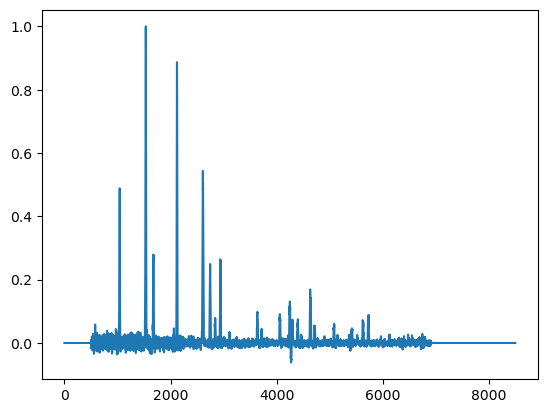

In [444]:
plt.plot(pv_xrd_normalized[0][0].cpu().numpy())

In [445]:
pv_xrd = pv_xrd_normalized

In [446]:
all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

#my code 
list_of_idxs = []
list_of_batchs = []

In [448]:
num_evals = 5

In [449]:
from pymatgen.core.lattice import Lattice
from pymatgen.core.structure import Structure
from pymatgen.io.cif import CifWriter

#pv_xrd = torch.tensor(powder_data_list[i], dtype = torch.float32).cuda().unsqueeze(0).unsqueeze(0)
for eval_idx in range(num_evals):
    try:
        _, _, z = model.encode(None, xrd_int, xrd_loc, torch.tensor([2,3]).cuda(), pv_xrd = pv_xrd)

        ld_kwargs = SimpleNamespace(n_step_each=100,
                                    step_lr=1e-4,
                                    min_sigma=0,
                                    save_traj=False,
                                    disable_bar=False)

        gt_atom_types = None

        outputs = model.langevin_dynamics(
                        z, ld_kwargs, gt_num_atoms, gt_atom_types, gt_atom_spec_torch)

        # collect sampled crystals in this batch.
        batch_frac_coords.append(outputs['frac_coords'].detach().cpu())
        batch_num_atoms.append(outputs['num_atoms'].detach().cpu())
        batch_atom_types.append(outputs['atom_types'].detach().cpu())
        batch_lengths.append(outputs['lengths'].detach().cpu())
        batch_angles.append(outputs['angles'].detach().cpu())
        if ld_kwargs.save_traj:
            batch_all_frac_coords.append(
                outputs['all_frac_coords'][::down_sample_traj_step].detach().cpu())
            batch_all_atom_types.append(
                outputs['all_atom_types'][::down_sample_traj_step].detach().cpu())
    except: 
        continue
        
# collect sampled crystals for this z.
frac_coords.append(torch.stack(batch_frac_coords, dim=0))
num_atoms.append(torch.stack(batch_num_atoms, dim=0))
atom_types.append(torch.stack(batch_atom_types, dim=0))
lengths.append(torch.stack(batch_lengths, dim=0))
angles.append(torch.stack(batch_angles, dim=0))
if ld_kwargs.save_traj:
    all_frac_coords_stack.append(
        torch.stack(batch_all_frac_coords, dim=0))
    all_atom_types_stack.append(
        torch.stack(batch_all_atom_types, dim=0))

input_data_list = input_data_list + batch_list_just_crossover
    # print(powder_files[i])
    # print(outputs)
    # gt_structure = Structure(
    #     lattice=Lattice.from_parameters(
    #     *(outputs['lengths'][0].tolist() + outputs['angles'][0].tolist())),
    #     species=outputs['atom_types'].tolist(), coords=outputs['frac_coords'].tolist(), coords_are_cartesian=False)
    # gt_writer = CifWriter(gt_structure)
    # gt_writer.write_file("/home/gridsan/groups/Freedman_CDVAE/expt_data/good/" + powder_files[i].split(".xyd")[0] + ".cif")

100%|██████████| 50/50 [01:52<00:00,  2.24s/it]


In [450]:
frac_coords = torch.cat(frac_coords, dim=1)

In [451]:
num_atoms = torch.cat(num_atoms, dim=1)
atom_types = torch.cat(atom_types, dim=1)
lengths = torch.cat(lengths, dim=1)
angles = torch.cat(angles, dim=1)
if ld_kwargs.save_traj:
    all_frac_coords_stack = torch.cat(all_frac_coords_stack, dim=2)
    all_atom_types_stack = torch.cat(all_atom_types_stack, dim=2)

In [452]:
input_data_batch = Batch.from_data_list(input_data_list)

In [453]:
(frac_coords, num_atoms, atom_types, lengths, angles,
         all_frac_coords_stack, all_atom_types_stack, input_data_batch) = (
        frac_coords, num_atoms, atom_types, lengths, angles,
        all_frac_coords_stack, all_atom_types_stack, input_data_batch)

In [454]:
recon_out_name = "freedman_experimetal_compounds.pt"

In [455]:
 torch.save({
            'eval_setting': "not relevant here",
            'input_data_batch': input_data_batch,
            'frac_coords': frac_coords,
            'num_atoms': num_atoms,
            'atom_types': atom_types,
            'lengths': lengths,
            'angles': angles,
            'all_frac_coords_stack': all_frac_coords_stack,
            'all_atom_types_stack': all_atom_types_stack,
            'time': 0,
        }, model_path + recon_out_name)

In [406]:
from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
from pymatgen.io.cif import CifWriter

#added by Tsach


from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)


CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}
import sys
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-05/mp_20_pv'
num_batches = 1
all_metrics = {}

cfg = load_config(model_path)
eval_model_name = cfg.data.eval_model_name
def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name

recon_file_path = get_file_paths(model_path, 'recon',label='mp_20')

# def get_crystal_array_list(file_path, batch_idx=0):
file_path = recon_file_path
data = load_data(file_path)
def get_crystals_list(
        frac_coords, atom_types, lengths, angles, num_atoms):
    """
    args:
        frac_coords: (num_atoms, 3)
        atom_types: (num_atoms)
        lengths: (num_crystals)
        angles: (num_crystals)
        num_atoms: (num_crystals)
    """
    assert frac_coords.size(0) == atom_types.size(0) == num_atoms.sum()
    assert lengths.size(0) == angles.size(0) == num_atoms.size(0)

    start_idx = 0
    crystal_array_list = []
    for batch_idx, num_atom in enumerate(num_atoms.tolist()):
        cur_frac_coords = frac_coords.narrow(0, start_idx, num_atom)
        cur_atom_types = atom_types.narrow(0, start_idx, num_atom)
        cur_lengths = lengths[batch_idx]
        cur_angles = angles[batch_idx]

        crystal_array_list.append({
            'frac_coords': cur_frac_coords.detach().cpu().numpy(),
            'atom_types': cur_atom_types.detach().cpu().numpy(),
            'lengths': cur_lengths.detach().cpu().numpy(),
            'angles': cur_angles.detach().cpu().numpy(),
        })
        start_idx = start_idx + num_atom
    return crystal_array_list

def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None

    return crys_array_list, true_crystal_array_list
class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)
class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()
from multiprocessing import Pool, cpu_count

def create_crystal(x):
    return Crystal(x)

In [456]:
model_path = "/home/gridsan/tmackey/hydra/singlerun/2024-01-11/augcag/"
recon_out_name = "freedman_experimetal_compounds.pt"
recon_file_path = model_path +  recon_out_name

In [457]:
# def get_crystal_array_list(file_path, batch_idx=0):
file_path = recon_file_path

In [458]:
file_path

'/home/gridsan/tmackey/hydra/singlerun/2024-01-11/augcag/freedman_experimetal_compounds.pt'

In [459]:
from tqdm import tqdm
gt_crys = []
counter = 0 
__, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=0)
true_crystal_array_list = true_crystal_array_list[0:256]

for x in tqdm(true_crystal_array_list): 
    gt_crys.append(Crystal(x))


100%|██████████| 15/15 [00:03<00:00,  4.85it/s]


In [461]:
num_batches = 5 #total is 64

total_rmsd = []

In [462]:
import os

results_dir = "/home/gridsan/tmackey/cdvae/scripts/1-05-2024_experimental_data/multiple_evals_results"

for eval_num in range(num_batches): 
    print("eval num is ", eval_num)
    crys_array_list, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=eval_num)

    crys_array_list = crys_array_list[0:256]

    pred_crys = []
    counter = 0
    for x in tqdm(crys_array_list): 
        pred_crys.append(Crystal(x))

    rec_evaluator = RecEval(pred_crys, gt_crys)
    recon_metrics = rec_evaluator.get_metrics()
    
    print(recon_metrics)
    
    total_rmsd.append(recon_metrics['rmsd_values'])

    file_name = os.path.join(results_dir, "eval_" + str(eval_num) + ".json")
    #save the rmsd values
    np.save(file_name, np.array(total_rmsd))

eval num is  0


100%|██████████| 15/15 [00:03<00:00,  4.29it/s]


[True, False, True, True, True, True, True, True, True, True, False, False, True, True, False]


100%|██████████| 15/15 [00:00<00:00, 267.91it/s]


{'match_rate': 0.06666666666666667, 'rms_dist': 0.4559110949478907, 'diff_dist': None, 'rmsd_values': array([None, None, None, 0.4559110949478907, None, None, None, None, None,
       None, None, None, None, None, None], dtype=object)}
eval num is  1


...

{'match_rate': 0.06666666666666667, 'rms_dist': 0.0593487729470467, 'diff_dist': None, 'rmsd_values': array([None, None, None, None, None, None, None, None, None, None, None,
       None, 0.0593487729470467, None, None], dtype=object)}
eval num is  4


100%|██████████| 15/15 [00:03<00:00,  4.12it/s]


[True, False, True, True, True, True, True, True, True, True, False, False, True, False, False]


100%|██████████| 15/15 [00:00<00:00, 159.01it/s]

{'match_rate': 0.2, 'rms_dist': 0.24045967746791722, 'diff_dist': None, 'rmsd_values': array([None, None, None, 0.39106778519996277, None, None, None,
       0.012590150919494596, 0.31772109628429435, None, None, None, None,
       None, None], dtype=object)}


In [463]:
total_rmsd_og = total_rmsd # for safekeeping

In [464]:
total_rmsd_array = np.array([[0 if x is None else x for x in sublist] for sublist in total_rmsd])

total_rmsd_array.shape  # To check the shape of the array (should be 64x256 for your case)


(5, 15)

In [465]:
column_sum = np.sum(total_rmsd_array, axis=0)

In [466]:
column_sum

array([0.        , 0.        , 0.        , 1.50394996, 0.        ,
       0.00699231, 0.        , 0.02293794, 0.37481902, 0.        ,
       0.        , 0.        , 0.37088554, 0.        , 0.        ])

In [467]:
np.mean(column_sum > 0)

0.3333333333333333

In [468]:
np.where(column_sum)

(array([ 3,  5,  7,  8, 12]),)

In [415]:
print(true_crystal_array_list[index])
print(crys_array_list[index])

{'frac_coords': array([[0.055723, 0.873929, 0.111446],
       [0.944277, 0.126071, 0.888554],
       [0.559217, 0.653716, 0.118434],
       [0.440783, 0.346284, 0.881566],
       [0.212957, 0.057071, 0.425914],
       [0.787043, 0.942929, 0.574086],
       [0.72725 , 0.585727, 0.4545  ],
       [0.27275 , 0.414273, 0.5455  ]], dtype=float32), 'atom_types': array([14, 14, 14, 14, 14, 14, 14, 14]), 'lengths': array([3.87174  , 6.360895 , 7.2086806], dtype=float32), 'angles': array([ 96.561584, 105.57783 ,  90.      ], dtype=float32)}
{'frac_coords': array([[0.64599514, 0.8656478 , 0.14539538],
       [0.14807175, 0.8654651 , 0.14889196],
       [0.6469349 , 0.36799717, 0.14288282],
       [0.6484464 , 0.3694844 , 0.64611214],
       [0.65175706, 0.8643395 , 0.644502  ],
       [0.14866064, 0.36614254, 0.14838713],
       [0.15121835, 0.8705281 , 0.6487943 ],
       [0.14966445, 0.363099  , 0.64448655]], dtype=float32), 'atom_types': array([14, 14, 14, 14, 14, 14, 14, 14]), 'lengths': arr

In [ ]:
print((outputs['lengths'][0].tolist() + outputs['angles'][0].tolist()))
gt_structure = Structure(
    lattice=Lattice.from_parameters(
    *(outputs['lengths'][0].tolist() + outputs['angles'][0].tolist())),
    species=outputs['atom_types'].tolist(), coords=outputs['frac_coords'].tolist(), coords_are_cartesian=False)
gt_writer = CifWriter(gt_structure)
print("./" + powder_files[0].split(".xyd")[0] + ".cif")
gt_writer.write_file("/home/gridsan/groups/Freedman_CDVAE/expt_data/good/" + powder_files[0].split(".xyd")[0] + ".cif")

In [6]:
pv_xrd = pv_xrd + torch.randn(pv_xrd.shape).cuda() * model.noise_sd 

In [12]:
print(pv_xrd[0].shape)

torch.Size([1, 8500])


In [24]:
import matplotlib.pyplot as plt

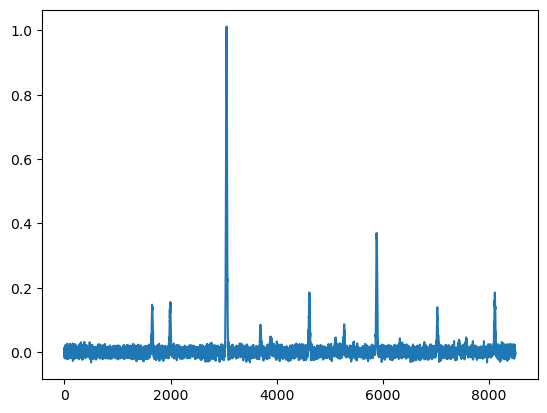

In [41]:
plt.plot(np.array(pv_xrd.cpu()[0][0]))

In [8]:
#_, _, z = model.encode(None, xrd_int, xrd_loc, atom_spec, pv_xrd = pv_xrd)
_, _, z = model.encode(None, xrd_int, xrd_loc, torch.tensor([2,3]).cuda(), pv_xrd = pv_xrd)

In [9]:
#number of steps set unusually low to get a rough estimate of performance
ld_kwargs = SimpleNamespace(n_step_each=100,
                                step_lr=1e-4,
                                min_sigma=0,
                                save_traj=False,
                                disable_bar=False)

In [23]:
"""
Bi 6
Si 8
Pb 4
PdBi2 12
FeO 8
V2O5 14
Ni 4
Fe 2
NiSb 4
NiPb 4
NiBi 4
InBi 4
In2Bi 6
NiBi3 16
InSb 8
Ba2ZrS4 14
BaBi3 4
Ti4CoBi2 28
MnBi 4
KBi2 24"""
num_atoms = [6,8,4,12,8,8,14,4,6,14,2,4,8,4,6,6,6,4,4,6,16,8,8,14,14,4,6,4,28,6,4,12,24,6,6,6]
atom_spec = [[83], [14], [82],[46,83],[26,8],[26,8],[23,8],[28],[83],[23,8],[26],[28,51],[26,8],[28,82],[83],[83],[83],[28,83],[49,83],[49,83],[28,83],[49,51],[26,8],[56,40,16],[23,8],[49,83],[83],[56,83],[22,27,83],[83],[25,83],[46,83],[19,83],[83],[83],[83]]

36


In [17]:
gt_atom_types = None
gt_num_atoms = torch.tensor([4]).cuda()

In [10]:
gt_atom_types = batch.atom_types
gt_num_atoms = batch.num_atoms

print(gt_num_atoms)
print(gt_atom_types)
print(atom_spec)

tensor([ 4,  4,  4,  4, 14, 14, 14, 14, 20, 20, 20, 20, 20, 20, 20, 20,  9,  9,
         9,  9,  4,  4,  4,  4, 12, 12, 12, 12, 10, 10, 10, 10,  2,  2,  2,  2,
        16, 16, 16, 16, 13, 13, 13, 13, 12, 12, 12, 12, 14, 14, 14, 14,  4,  4,
         4,  4,  4,  4,  4,  4, 20, 20, 20, 20, 10, 10, 10, 10,  6,  6,  6,  6,
        16, 16, 16, 16,  4,  4,  4,  4,  8,  8,  8,  8, 16, 16, 16, 16,  6,  6,
         6,  6,  7,  7,  7,  7, 14, 14, 14, 14,  4,  4,  4,  4,  4,  4,  4,  4,
        18, 18, 18, 18, 15, 15, 15, 15, 18, 18, 18, 18,  8,  8,  8,  8,  2,  2,
         2,  2, 12, 12, 12, 12,  4,  4,  4,  4,  4,  4,  4,  4,  9,  9,  9,  9,
         6,  6,  6,  6, 16, 16, 16, 16,  6,  6,  6,  6,  4,  4,  4,  4,  2,  2,
         2,  2, 16, 16, 16, 16,  4,  4,  4,  4, 12, 12, 12, 12,  2,  2,  2,  2,
        17, 17, 17, 17,  6,  6,  6,  6, 10, 10, 10, 10, 14, 14, 14, 14, 18, 18,
        18, 18,  3,  3,  3,  3, 13, 13, 13, 13, 12, 12, 12, 12,  7,  7,  7,  7,
         5,  5,  5,  5,  9,  9,  9,  9, 

In [15]:
gt_atom_types = None

print(gt_num_atoms)
print(gt_atom_types)
print(atom_spec)

outputs = model.langevin_dynamics(
                    z, ld_kwargs, gt_num_atoms, gt_atom_types, atom_spec)

tensor([ 4,  4,  4,  4, 14, 14, 14, 14, 20, 20, 20, 20, 20, 20, 20, 20,  9,  9,
         9,  9,  4,  4,  4,  4, 12, 12, 12, 12, 10, 10, 10, 10,  2,  2,  2,  2,
        16, 16, 16, 16, 13, 13, 13, 13, 12, 12, 12, 12, 14, 14, 14, 14,  4,  4,
         4,  4,  4,  4,  4,  4, 20, 20, 20, 20, 10, 10, 10, 10,  6,  6,  6,  6,
        16, 16, 16, 16,  4,  4,  4,  4,  8,  8,  8,  8, 16, 16, 16, 16,  6,  6,
         6,  6,  7,  7,  7,  7, 14, 14, 14, 14,  4,  4,  4,  4,  4,  4,  4,  4,
        18, 18, 18, 18, 15, 15, 15, 15, 18, 18, 18, 18,  8,  8,  8,  8,  2,  2,
         2,  2, 12, 12, 12, 12,  4,  4,  4,  4,  4,  4,  4,  4,  9,  9,  9,  9,
         6,  6,  6,  6, 16, 16, 16, 16,  6,  6,  6,  6,  4,  4,  4,  4,  2,  2,
         2,  2, 16, 16, 16, 16,  4,  4,  4,  4, 12, 12, 12, 12,  2,  2,  2,  2,
        17, 17, 17, 17,  6,  6,  6,  6, 10, 10, 10, 10, 14, 14, 14, 14, 18, 18,
        18, 18,  3,  3,  3,  3, 13, 13, 13, 13, 12, 12, 12, 12,  7,  7,  7,  7,
         5,  5,  5,  5,  9,  9,  9,  9, 

 16%|█▌        | 8/50 [02:12<11:37, 16.61s/it]


KeyboardInterrupt: 

In [ ]:
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
import numpy as np
import os
from numpy.polynomial import chebyshev
from scipy import interpolate


def background_subtraction(x_data, y_data, cheb_order = 5, std_mult = 10, tolerance = 1e-8):
    def exclude_outliers(x, y, fit_y, std_mult = 3):
        y_bs = y - fit_y
        mean = np.mean(y_bs)
        std = np.std(y_bs)
        outlier_mask = (y_bs < mean + std * std_mult) & (y_bs > mean - std * std_mult)
        x_data = x[outlier_mask]
        y_data = y[outlier_mask]
        return x_data, y_data

    def chebyshev_fit(x, *coeffs):
        # Use the first 3 Chebyshev polynomials of the first kind
        return sum(c * chebyshev.chebval(x, [0] * i + [1]) for i, c in enumerate(coeffs))

    y_data = y_data / np.max(y_data)
    
    x_data_background = x_data
    background = y_data
    fit_y = [0] * len(background)
    initial_guess = [0] * cheb_order
    counter = 0
    
    while abs(sum(fit_y - background)/len(fit_y)) > tolerance and counter < 20:
        popt, _ = optimize.curve_fit(chebyshev_fit, x_data_background, background, p0=initial_guess)
        fit_y = chebyshev_fit(x_data_background, *popt)
        x_data_background, background = exclude_outliers(x_data_background, background, fit_y, std_mult=3)
        fit_y = chebyshev_fit(x_data_background, *popt)
        counter += 1
    
    if counter == 20:
        print("This model may perform poorly on data with a complicated background")
        
    popt, _ = optimize.curve_fit(chebyshev_fit, x_data_background, background, p0=initial_guess)

    # Generate fitted y values
    fit_y = chebyshev_fit(x_data, *popt)

    # Subtract fitted y values from data
    y_data = y_data - fit_y

    return y_data


powder_file_dir = "/home/gridsan/groups/Freedman_CDVAE/expt_data/good/"
#powder_files = os.listdir(powder_file_dir)
powder_files = ['Bi_aba_vbi_ballmill_nsls_15_4.xyd', 'Si_bcb_si_glovebox.xyd', 'Pb_i_86_1_nipbelementalcontrol.xyd', 'PdBi2_ear_i_0fillin_pdbi2_cathy.xyd', 'FeO_feo_2.001.xyd', 'FeO_feo_2.003.xyd', 'V2O5_rak_v2o5_box.xyd', 'Ni_adt_2_12_2_dark_ni_sn.xyd', 'Bi_aba_2_147_bt_febi_saltmeta_redo.xyd', 'V2O5_rak_v2o5_air.xyd', 'Fe_2021_01_05_fe_byadt.xyd', 'NiSb_adt_2_12_4_purple_ni_sb.xyd', 'FeO_feo_2.002.xyd', 'V2O5_aba_v2so5_sm.xyd', 'NiPb_i_86_1liberatedxtalstake5.xyd', 'Bi_aba_febi_ballmilled_1_20.xyd', 'Bi_aba_febi_ballmilled_11_20_reedo.xyd', 'Bi_aba_febi_ballmill_beamtime_20_3.xyd', 'NiBi_bcb_i_1_1_nibi.xyd', 'InBi_ear_i_0fillin_inbi.xyd', 'In2Bi_ear_i_0fillin_in2bi_040221.xyd', 'NiBi3_ear_i_055_nibi3.xyd', 'InSb_ear_i_0fillin_in2sbbi.xyd', 'FeO_feo_short.xyd', 'Ba2ZrS4_aba_2_117_ba2zrs4_check.xyd', 'InBi_ear_i_0fillin_inbi_032821.xyd', 'Bi_aba_febi_ballmilled_11_20.xyd', 'BaBi3_adt_i_143_1_babi.xyd', 'Ti4CoBi2_20210126_ckb_i_ti4cobi2_samplei.xyd', 'Bi_aba_2_147_bt_febi_ballmilled_redo3.xyd', 'MnBi_aba_smc_mnbi_xstal.xyd', 'PdBi2_ear_i_056_pdbi2.xyd', 'KBi2_aba_2_127_kbi2.xyd', 'Bi_aba_2_147_mnbi_ballmill.xyd', 'Bi_aba_febi_ballmill_1.xyd', 'Bi_aba_2_147_rubi_ballmilled.xyd']
print(powder_files)
print(len(powder_files))

powder_data_list = []
for file in powder_files:
    if file.endswith(".xyd"):
        data = pd.read_csv(powder_file_dir + file, sep='\s+', header=None, names=['x', 'y', 'd'])
        x_data = np.array(data['x'])
        y_data = np.array(data['y'])
        y_data = background_subtraction(x_data, y_data)
        
        #normalize the background_subtracted y data
        y_data = y_data / np.max(y_data)
        
        y_data_function = interpolate.UnivariateSpline(x_data, y_data, k = 1, s = 0.00001)
#        plt.plot(x_data, y_data, color = 'red')

        new_x_data = np.linspace(5, 89.9, num = 8500)
        new_y_data = y_data_function(new_x_data)
        
        if x_data[0] - new_x_data[0] > 0:
            for i in range(round((x_data[0] - new_x_data[0])/0.01)):
                new_y_data[i] = 0
        
        if x_data[-1] - new_x_data[-1] < 0:
            for i in range(round((new_x_data[-1] - x_data[-1])/0.01)):
                new_y_data[-(i+1)] = 0
        
#        plt.plot(new_x_data, new_y_data, color = 'blue')
#        plt.show()
#        plt.close()
        
        powder_data_list.append(new_y_data)


#for power_data in powder_data_list:
#    plt.plot(new_x_data, new_y_data)
#plt.show()